<a href="https://colab.research.google.com/github/mohammadarifshaikh/Research-with-Data-Science/blob/main/cybersecurity_intrusion_detection_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ASSIGNMENT**

1. Load & Inspect: Load CSV, print shape, missing values, and class distribution

In [8]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [9]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/datasets/cybersecurity_intrusion_data.csv')
print(f"Shape: {df.shape}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (9537, 11)


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [10]:
#check missing values
missing = df.isnull().sum()
print("Missing values per column:\n", missing[missing > 0])

Missing values per column:
 encryption_used    1966
dtype: int64


In [11]:
#check class distribution
print("\nLabels:\n", df['attack_detected'].value_counts().sort_index())
print("\nClass mapping: 0=Normal, 1=Attack Detected")



Labels:
 attack_detected
0    5273
1    4264
Name: count, dtype: int64

Class mapping: 0=Normal, 1=Attack Detected


2. Preprocess: Drop irrelevant columns, fill missing values with median, scale features, split 80/20

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


df = pd.read_csv('/content/drive/MyDrive/datasets/cybersecurity_intrusion_data.csv')

# Drop irrelevant column
df.drop(columns=['session_id'], inplace=True)

# Fill missing numerical values with median
df.fillna(df.median(numeric_only=True), inplace=True)

# Fill missing categorical values with mode
df['encryption_used'] = df['encryption_used'].fillna(
    df['encryption_used'].mode()[0]
)

# Separate features and target
X = df.drop(columns=['attack_detected'])
y = df['attack_detected']

# Convert categorical columns to numerical
X = pd.get_dummies(X, drop_first=True)

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=20,
    stratify=y
)

# Scale features AFTER splitting
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Print dataset sizes
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 7629 | Test: 1908


3. EDA: Bar chart of class distribution + top-10 feature correlations

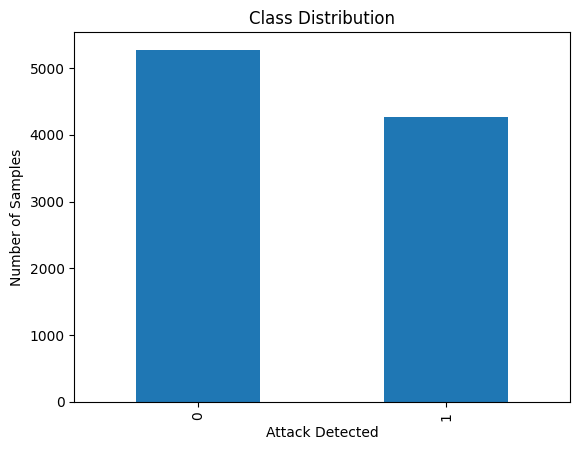

Top-10 Feature Correlations:
failed_logins           0.363726
login_attempts          0.277320
ip_reputation_score     0.211540
browser_type_Unknown    0.134630
session_duration        0.041602
browser_type_Safari     0.013289
browser_type_Firefox    0.010556
unusual_time_access     0.008652
encryption_used_DES     0.008306
browser_type_Edge       0.008057
Name: attack_detected, dtype: float64


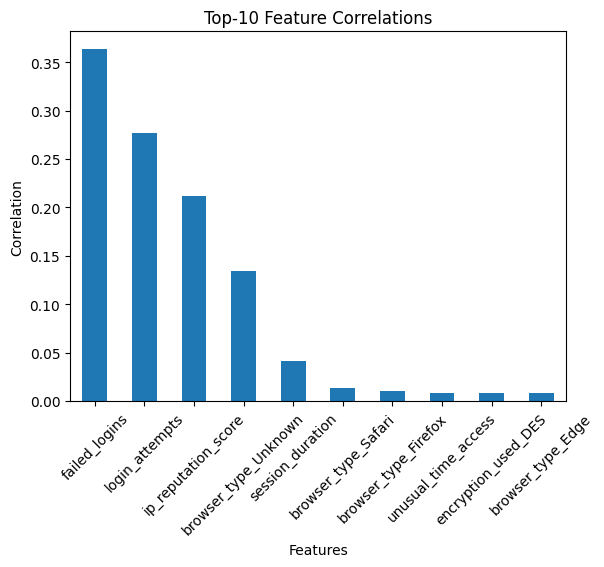

In [18]:

# Class Distribution
df['attack_detected'].value_counts().plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Attack Detected")
plt.ylabel("Number of Samples")
plt.show()



# Top-10 Correlations


# Convert categorical data to numbers
df_encoded = pd.get_dummies(df, drop_first=True)

# Find correlations
correlation = df_encoded.corr()['attack_detected']

# Remove target
correlation = correlation.drop('attack_detected')

# Top 10
top_10 = correlation.abs().sort_values(ascending=False).head(10)

print("Top-10 Feature Correlations:")
print(top_10)

# Plot top 10
top_10.plot(kind='bar')

plt.title("Top-10 Feature Correlations")
plt.xlabel("Features")
plt.ylabel("Correlation")
plt.xticks(rotation=45)
plt.show()

4. Train Models: Decision Tree, KNN (k=5), Logistic Regression — report Accuracy, Precision, Recall, F1

In [19]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=20),
    'KNN (k=5)':     KNeighborsClassifier(n_neighbors=5),
    'Logistic Reg':  LogisticRegression(max_iter=1000, random_state=20)
}
results, predictions = {}, {}

for name, m in models.items():
    m.fit(X_train, y_train)
    yp = m.predict(X_test)
    predictions[name] = yp
    results[name] = {
        'Accuracy':  accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall':    recall_score(y_test, yp, average='weighted'),
        'F1-Score':  f1_score(y_test, yp, average='weighted')
    }
    print(f"{name}: Acc={results[name]['Accuracy']:.4f}  Precision = {results[name]['Precision']:.4f} Recall = {results[name]['Recall']:.4f} F1={results[name]['F1-Score']:.4f}")


Decision Tree: Acc=0.8145  Precision = 0.8158 Recall = 0.8145 F1=0.8148
KNN (k=5): Acc=0.8050  Precision = 0.8157 Recall = 0.8050 F1=0.8004
Logistic Reg: Acc=0.7490  Precision = 0.7482 Recall = 0.7490 F1=0.7482


5. Depth Tuning: Decision Tree with max_depth = [3, 5, 10, 15, 20, None] — table + bar chart

           Accuracy  Precision  Recall  F1-Score
max_depth                                       
3            0.8747     0.8979  0.8747    0.8709
5            0.8947     0.9115  0.8947    0.8922
10           0.8952     0.9090  0.8952    0.8930
15           0.8800     0.8868  0.8800    0.8783
20           0.8595     0.8607  0.8595    0.8587
None         0.8145     0.8158  0.8145    0.8148


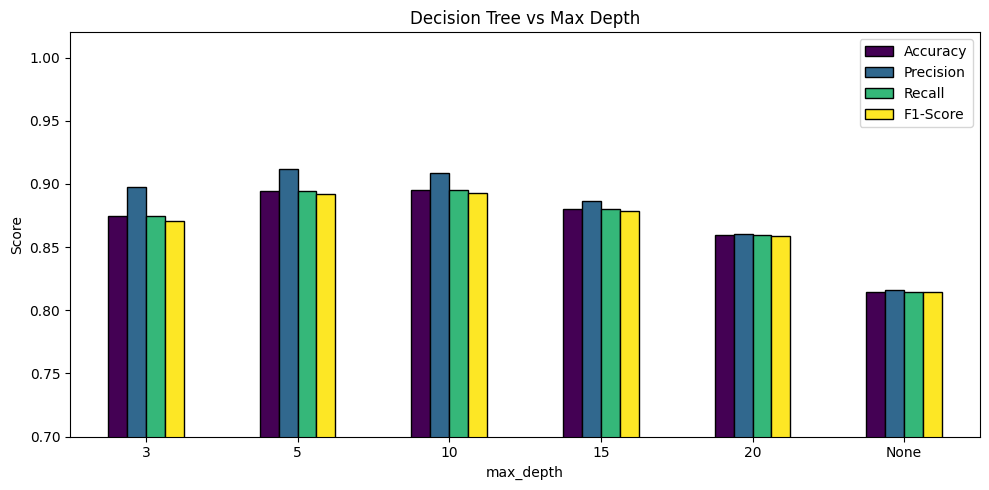

In [20]:
dt_results = []
for d in [3, 5, 10, 15, 20, None]:
    dt = DecisionTreeClassifier(max_depth=d, random_state=20).fit(X_train, y_train)
    yp = dt.predict(X_test)
    dt_results.append({'max_depth': str(d) or 'None',
        'Accuracy': accuracy_score(y_test, yp), 'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall': recall_score(y_test, yp, average='weighted'), 'F1-Score': f1_score(y_test, yp, average='weighted')})

dt_df = pd.DataFrame(dt_results).set_index('max_depth')
print(dt_df.round(4))
dt_df.plot(kind='bar', figsize=(10,5), colormap='viridis', edgecolor='black')
plt.title('Decision Tree vs Max Depth'); plt.ylabel('Score'); plt.ylim(0.7, 1.02); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

6. Evaluate: Classification reports + 1×3 confusion matrix grid + model comparison bar chart

Classification Reports

In [22]:
target_names = ['Normal', 'Attack Detected']
for name, yp in predictions.items():
    print(f"\n{'='*55}\n{name}\n{'='*55}")
    print(classification_report(y_test, yp, target_names=target_names, digits=4))


Decision Tree
                 precision    recall  f1-score   support

         Normal     0.8453    0.8133    0.8290      1055
Attack Detected     0.7794    0.8159    0.7973       853

       accuracy                         0.8145      1908
      macro avg     0.8124    0.8146    0.8131      1908
   weighted avg     0.8158    0.8145    0.8148      1908


KNN (k=5)
                 precision    recall  f1-score   support

         Normal     0.7712    0.9204    0.8392      1055
Attack Detected     0.8706    0.6624    0.7523       853

       accuracy                         0.8050      1908
      macro avg     0.8209    0.7914    0.7958      1908
   weighted avg     0.8157    0.8050    0.8004      1908


Logistic Reg
                 precision    recall  f1-score   support

         Normal     0.7618    0.7943    0.7777      1055
Attack Detected     0.7314    0.6928    0.7116       853

       accuracy                         0.7490      1908
      macro avg     0.7466    0.7436    

1×3 confusion matrix grid

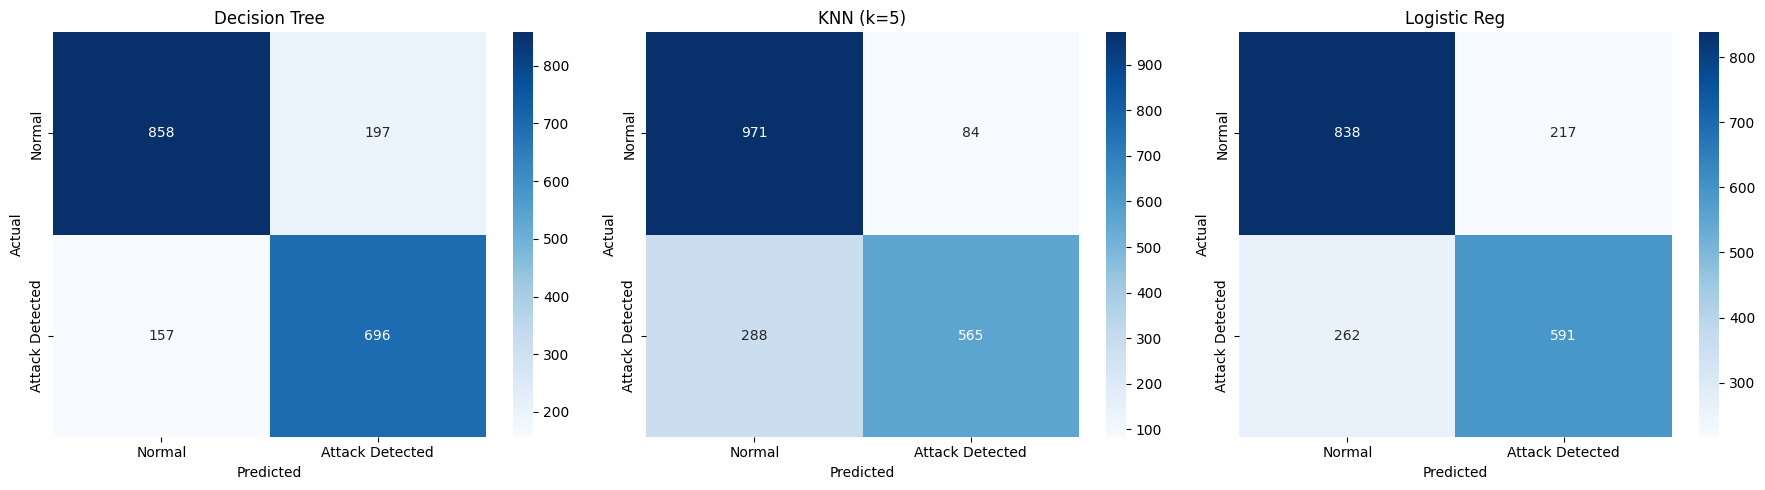

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, yp) in zip(axes, predictions.items()):
    sns.heatmap(confusion_matrix(y_test, yp), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=target_names, yticklabels=target_names)
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

model comparison bar chart

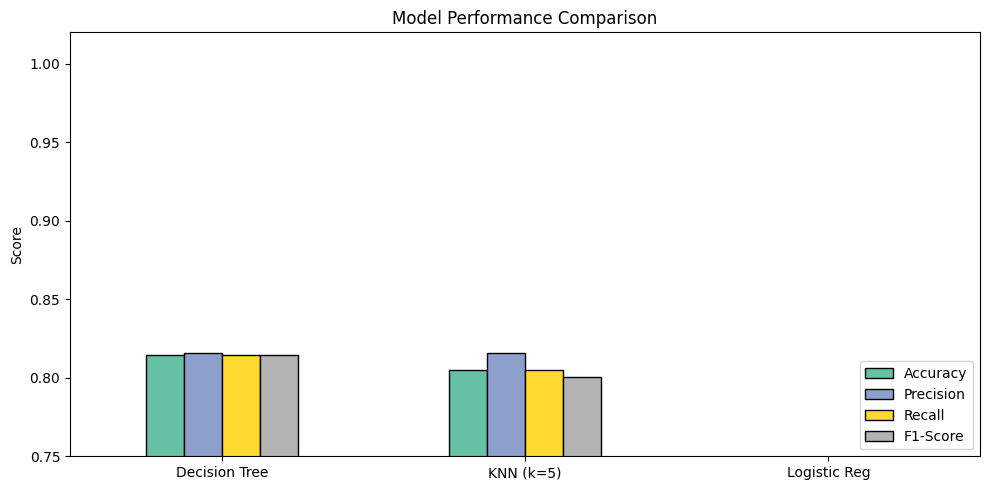


Summary:
                Accuracy  Precision  Recall  F1-Score
Decision Tree    0.8145     0.8158  0.8145    0.8148
KNN (k=5)        0.8050     0.8157  0.8050    0.8004
Logistic Reg     0.7490     0.7482  0.7490    0.7482


In [24]:
res_df = pd.DataFrame(results).T
res_df.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Model Performance Comparison'); plt.ylabel('Score'); plt.ylim(0.75, 1.02)
plt.xticks(rotation=0); plt.legend(loc='lower right'); plt.tight_layout(); plt.show()
print("\nSummary:\n", res_df.round(4))